In [33]:
# Load packages 
import os 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# set the working directory 
os.chdir('C:/Users/abc/OneDrive - UGent/Documenten/Derick Malavi_PhD Docs_UGent/Manuscript 4_Coffee')

In [35]:
# Read_data
ground_raw = pd.read_csv('coffee_data_pycleaned.csv')
ground_msc_sg_2d = pd.read_csv('coffee_ground_msc_sg_2d.csv')
ground_snv_sg_1d = pd.read_csv('coffee_ground_snv_sg_1d.csv')

In [36]:
# Check the shape of the data
print(ground_raw.shape)
print(ground_msc_sg_2d.shape)

(1469, 229)
(1469, 229)


In [37]:
# Check the first few rows 
ground_raw.head(5)

,sample_id,binary_class,three_class,adult_percent,cal_val,935.609985,939.059998,942.52002,945.97998,949.429993,...,1688.02002,1691.589966,1695.170044,1698.75,1702.329956,1705.910034,1709.48999,1713.069946,1716.650024,1720.22998
0,Pure_Arabica_10,pure_arabica,pure_arabica,0,1,0.347876,0.349376,0.363904,0.375547,0.384829,...,0.520932,0.512153,0.502902,0.492153,0.481531,0.470791,0.460815,0.450851,0.441252,0.430884
1,Pure_Arabica_3,pure_arabica,pure_arabica,0,1,0.332850,0.334093,0.346032,0.356395,0.364701,...,0.529074,0.519696,0.509692,0.497895,0.486415,0.474300,0.463489,0.452816,0.442621,0.432088
2,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,0.347639,0.349199,0.363783,0.375387,0.384600,...,0.536934,0.527794,0.518312,0.507230,0.496132,0.484015,0.474116,0.463680,0.453512,0.442852
3,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,0.338413,0.339599,0.350815,0.362448,0.370806,...,0.519080,0.510286,0.500799,0.489834,0.479003,0.467816,0.457893,0.447762,0.437734,0.427460
4,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,0.343888,0.345065,0.357601,0.368907,0.377726,...,0.528300,0.519557,0.510316,0.499657,0.489016,0.477639,0.467895,0.458040,0.447648,0.436710


In [38]:
ground_msc_sg_2d.head(5)

,sample_id,binary_class,three_class,adult_percent,cal_val,935.609985,939.059998,942.52002,945.97998,949.429993,...,1688.02002,1691.589966,1695.170044,1698.75,1702.329956,1705.910034,1709.48999,1713.069946,1716.650024,1720.22998
0,Pure_Arabica_10,pure_arabica,pure_arabica,0,1,-0.000838,-0.000838,-0.000838,-0.000838,-0.000838,...,-0.000658,-0.000619,-0.000515,-0.000377,-0.000377,-0.000377,-0.000377,-0.000377,-0.000377,-0.000377
1,Pure_Arabica_3,pure_arabica,pure_arabica,0,1,-0.000654,-0.000654,-0.000654,-0.000654,-0.000654,...,-0.000777,-0.000723,-0.000591,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411
2,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,-0.000797,-0.000797,-0.000797,-0.000797,-0.000797,...,-0.000730,-0.000671,-0.000553,-0.000399,-0.000399,-0.000399,-0.000399,-0.000399,-0.000399,-0.000399
3,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,-0.000678,-0.000678,-0.000678,-0.000678,-0.000678,...,-0.000737,-0.000669,-0.000546,-0.000391,-0.000391,-0.000391,-0.000391,-0.000391,-0.000391,-0.000391
4,Pure_Arabica_2,pure_arabica,pure_arabica,0,1,-0.000704,-0.000704,-0.000704,-0.000704,-0.000704,...,-0.000652,-0.000609,-0.000525,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411,-0.000411


In [39]:
# Select the X columns
X_raw = ground_raw.iloc[:,5:230]
X_msc_sg = ground_msc_sg_2d.iloc[:,5:230]
X_snv_sg = ground_snv_sg_1d.iloc[:,5:230]

In [40]:
X_raw.head(2)

,935.609985,939.059998,942.52002,945.97998,949.429993,952.890015,956.349976,959.809998,963.27002,966.72998,...,1688.02002,1691.589966,1695.170044,1698.75,1702.329956,1705.910034,1709.48999,1713.069946,1716.650024,1720.22998
0,0.347876,0.349376,0.363904,0.375547,0.384829,0.392920,0.398859,0.403592,0.408170,0.412234,...,0.520932,0.512153,0.502902,0.492153,0.481531,0.470791,0.460815,0.450851,0.441252,0.430884
1,0.332850,0.334093,0.346032,0.356395,0.364701,0.372712,0.378541,0.383322,0.387886,0.391924,...,0.529074,0.519696,0.509692,0.497895,0.486415,0.474300,0.463489,0.452816,0.442621,0.432088


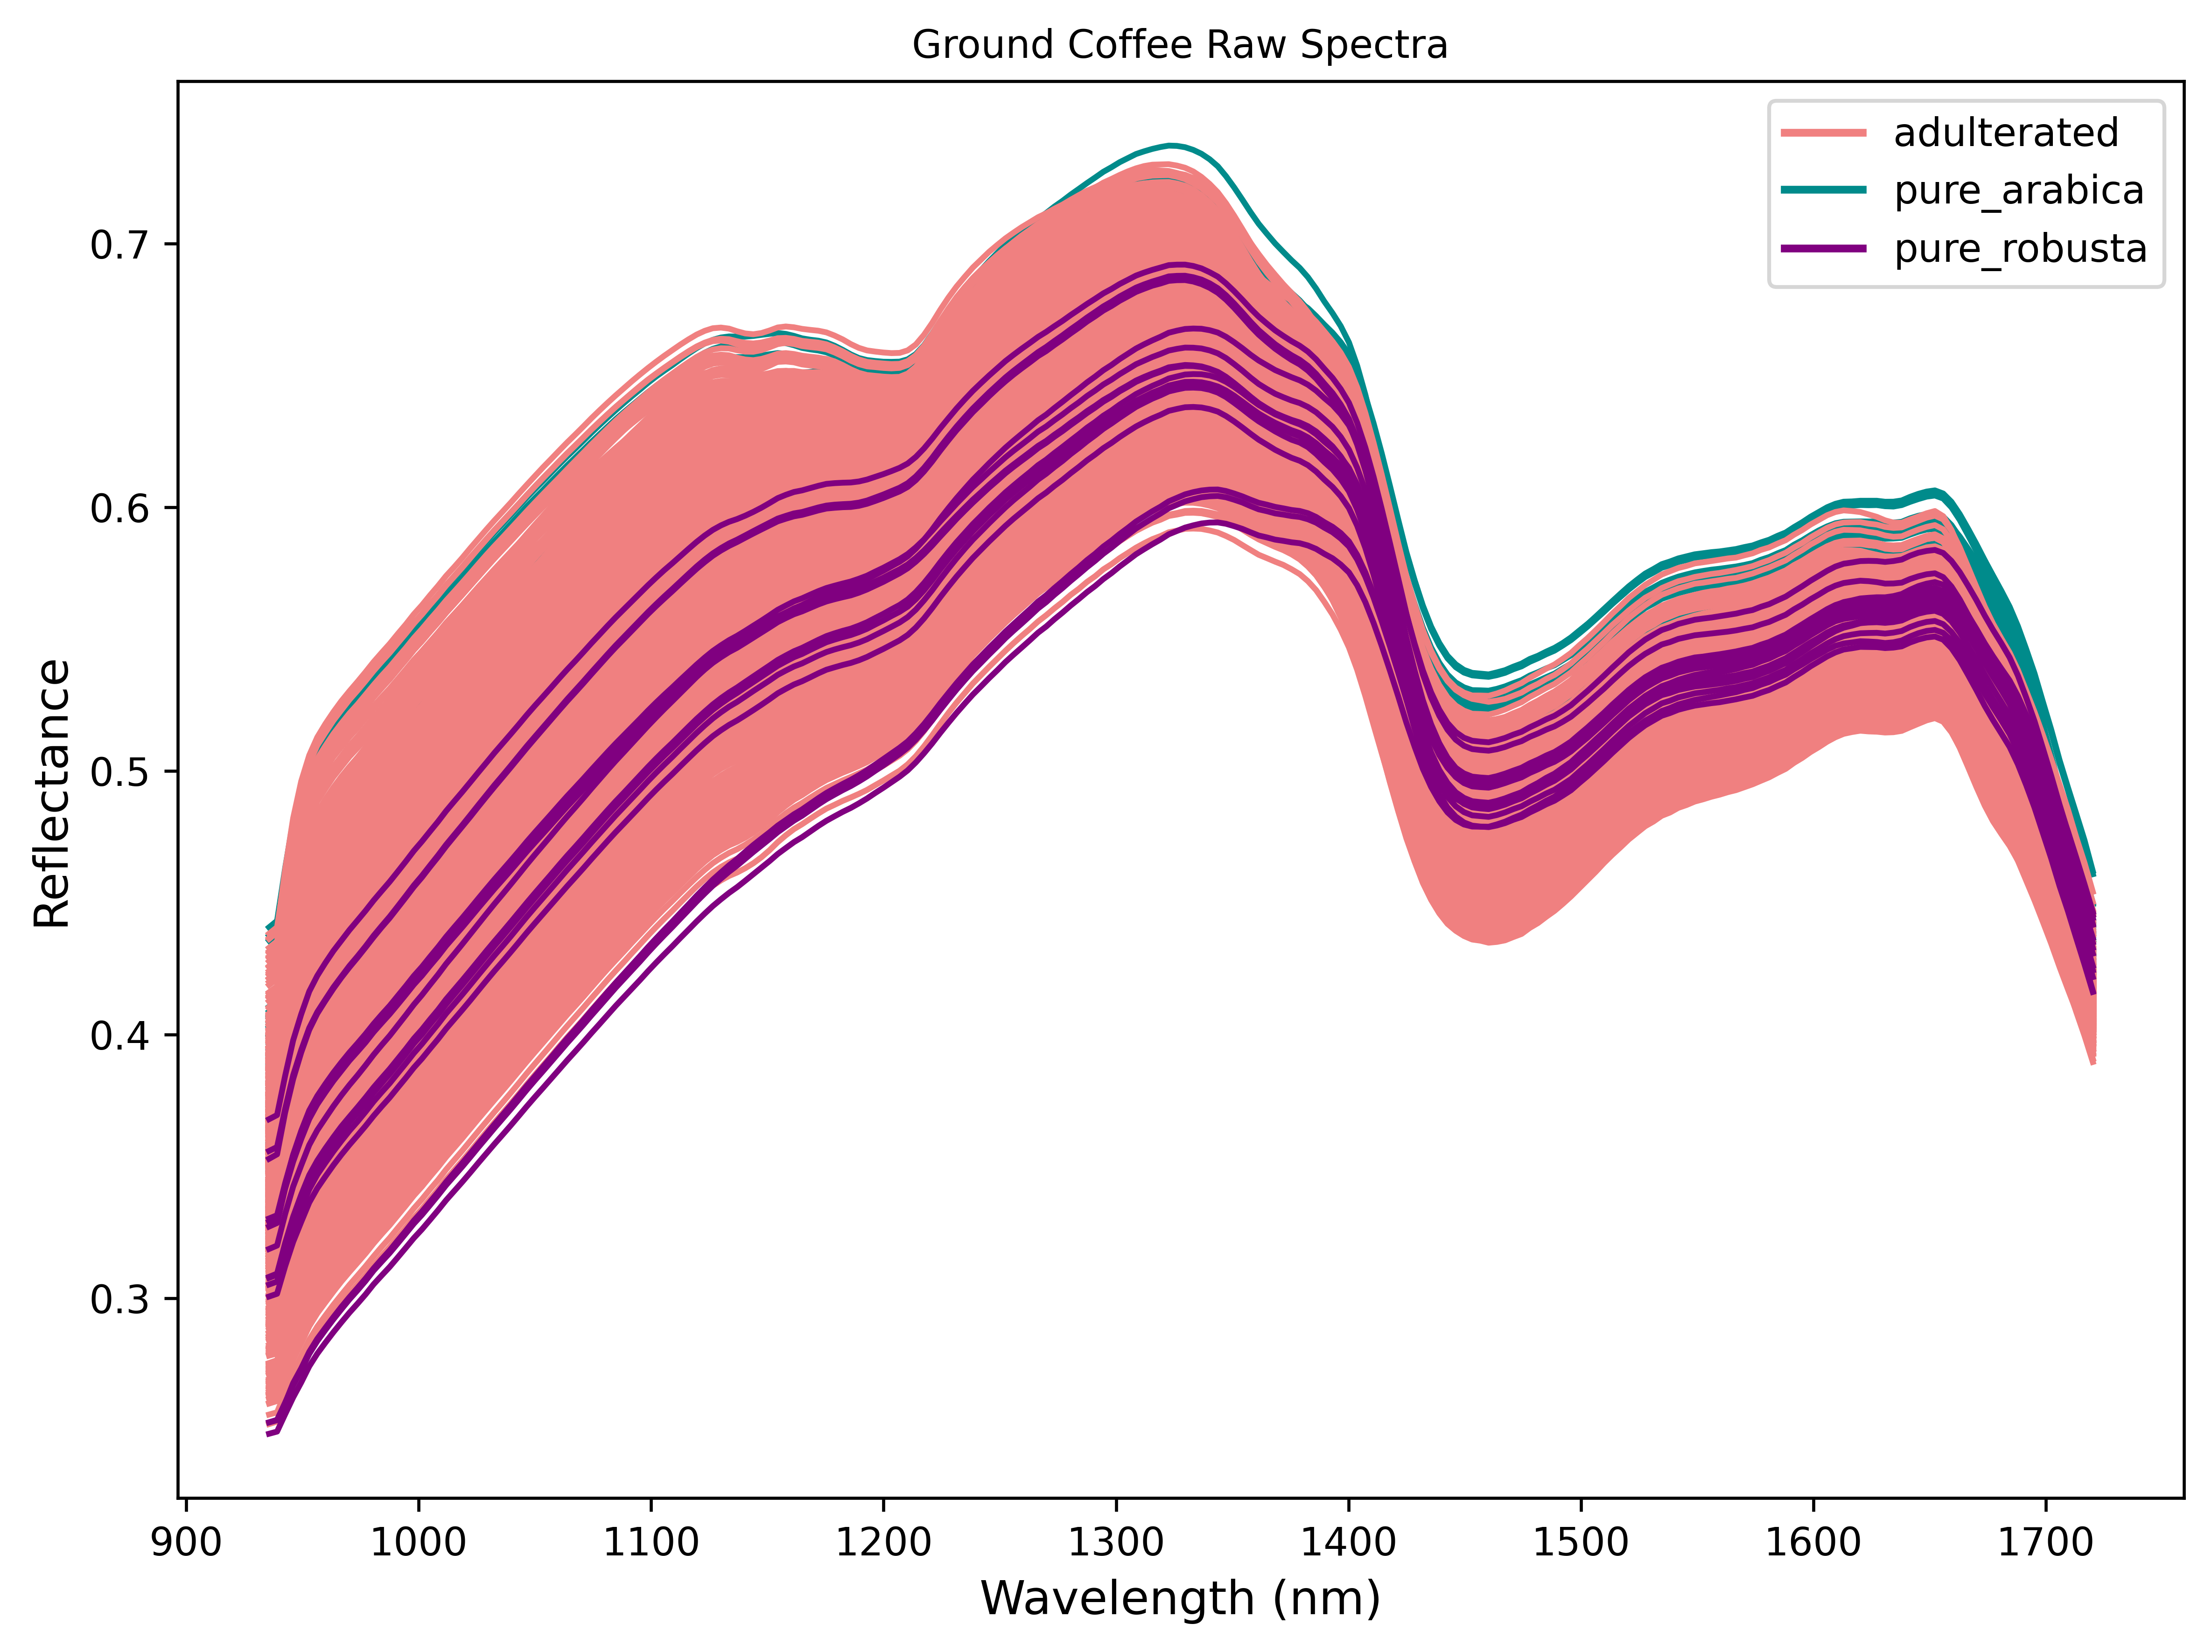

In [41]:
# Raw spectra
# Define the three classes
three_class = ground_raw['three_class']

# Extract the spectral wavelengths 
wavelengths = X_raw.columns.astype(float)

# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_raw.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Ground Coffee Raw Spectra', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("Ground_Coffee_Spectra.png", dpi=600, bbox_inches="tight", format="png")

# Show the plot
plt.show()

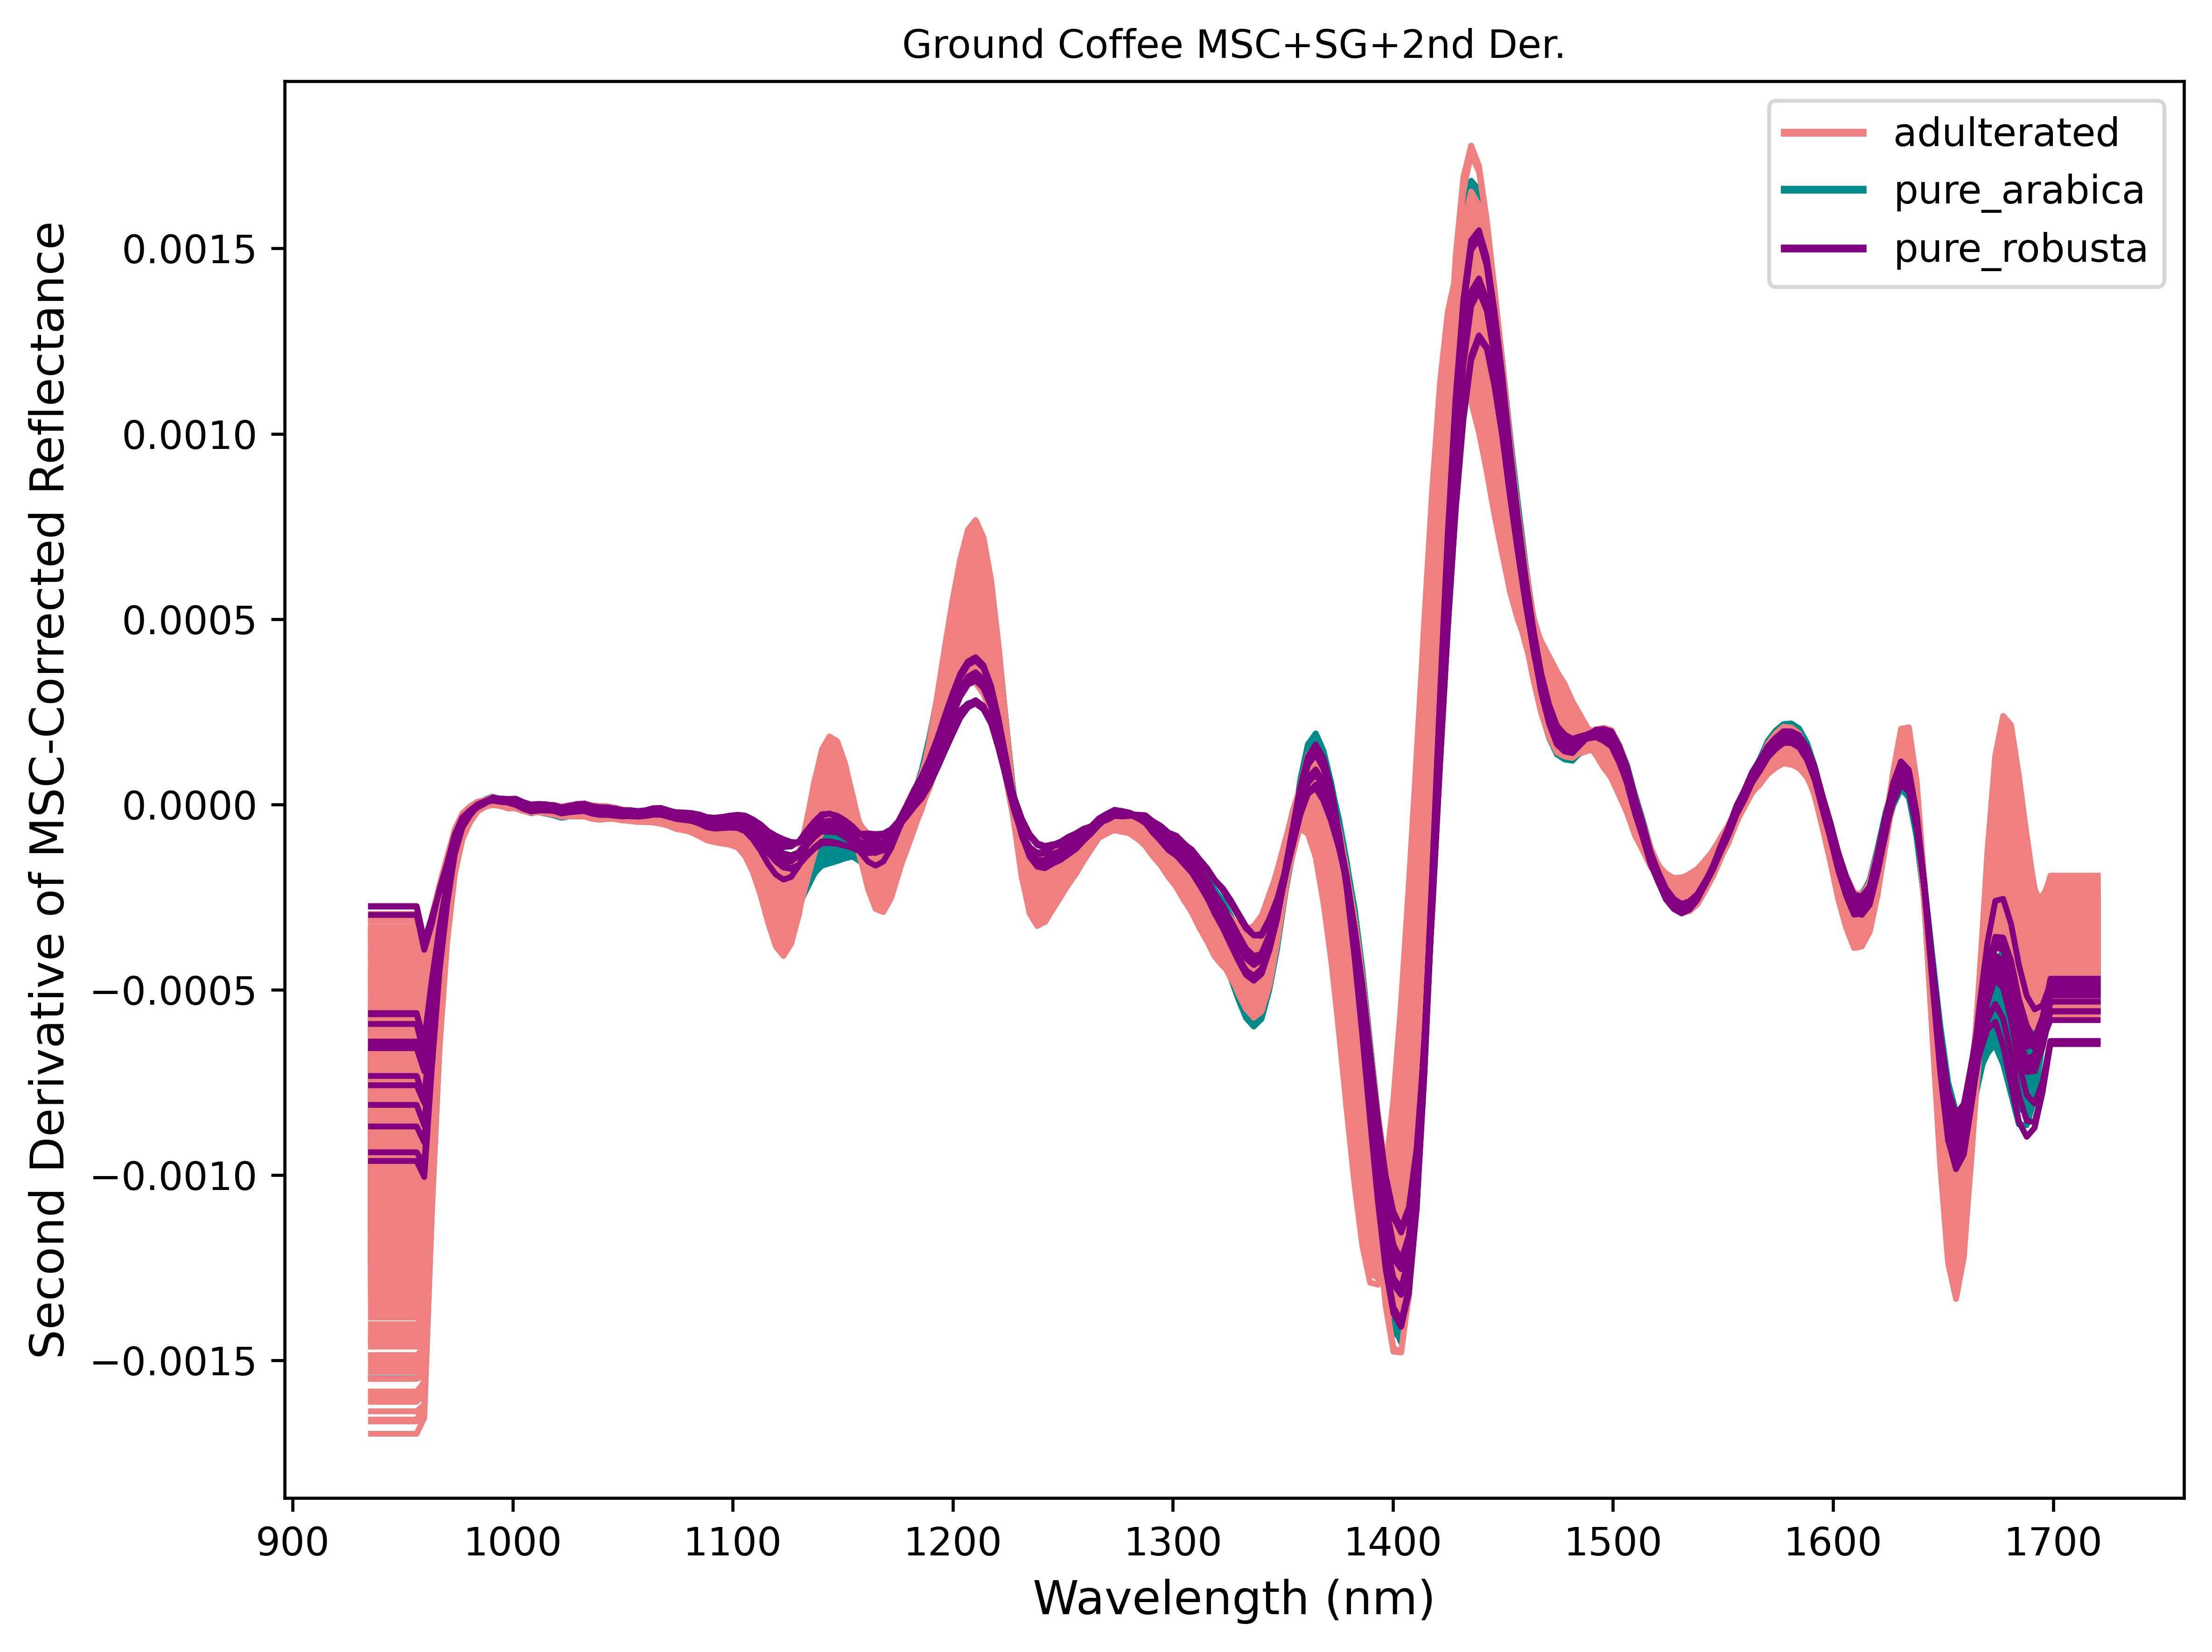

In [42]:
# Extract the spectral wavelengths 
wavelengths = X_msc_sg.columns.astype(float)

# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_msc_sg.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Ground Coffee MSC+SG+2nd Der.', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('Second Derivative of MSC-Corrected Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("Ground_Coffee_Spectra_MSC_SG_2D.png", dpi=300, bbox_inches="tight", format="png")

# Show the plot
plt.show()

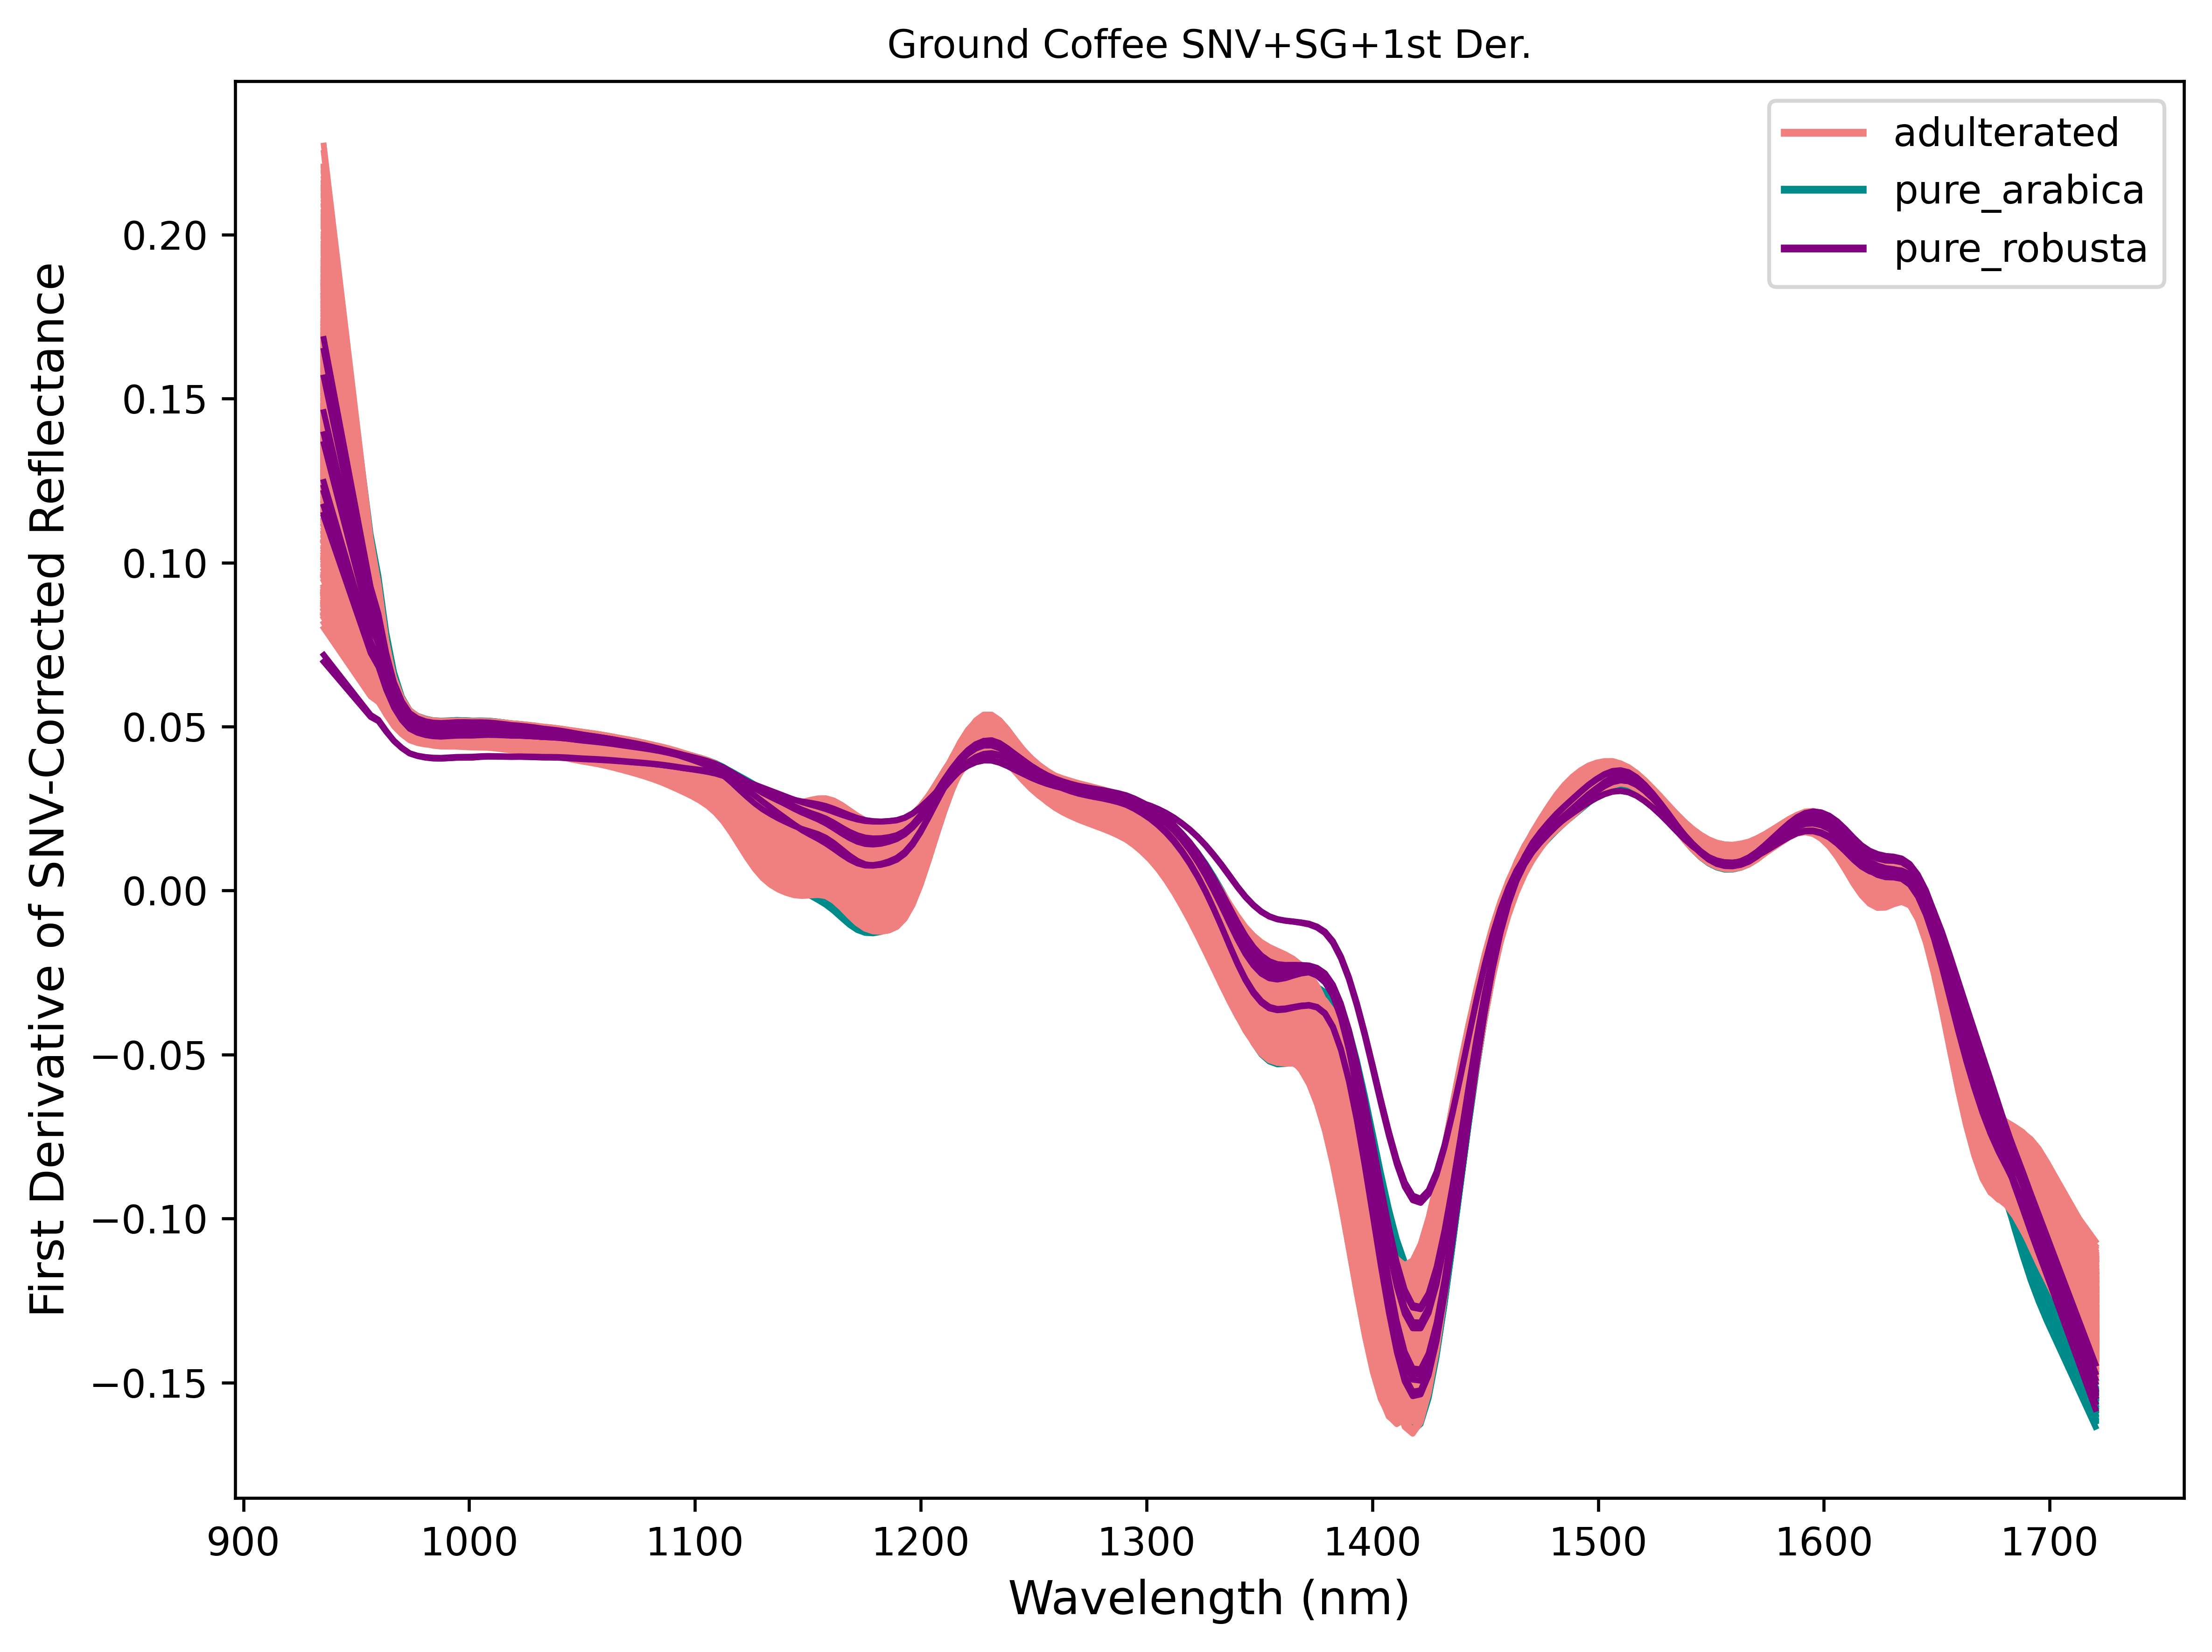

In [43]:
# SNV plus derivatives

# Extract the spectral wavelengths 
wavelengths = X_snv_sg.columns.astype(float)

# Define the color pallete 
palette = {"adulterated": "lightcoral", "pure_arabica": "darkcyan", "pure_robusta": "purple"}

# Plot the spectral data with colors based on the three_class
plt.figure(figsize=(8, 6),dpi=600)

# Iterate over each row and plot, using the three_class to color each sample
for index, row in X_snv_sg.iterrows():
    class_label = three_class.iloc[index]
    plt.plot(wavelengths, row, color=palette[class_label], label=class_label if index == 0 else "", alpha=1.0)

# Add title and labels
plt.title('Ground Coffee SNV+SG+1st Der.', fontsize=10)
plt.xlabel('Wavelength (nm)', fontsize=12)
plt.ylabel('First Derivative of SNV-Corrected Reflectance', fontsize=12)

# Add legend
handles = [plt.Line2D([0], [0], color=palette[class_label], lw=2) for class_label in palette]
labels = palette.keys()
plt.grid(False)
plt.legend(handles, labels, loc='upper right')
plt.tight_layout()

# Save the figure with high resolution
plt.savefig("Ground_Coffee_Spectra_SNV_SG_1D.png", dpi=600, bbox_inches="tight", format="png")

# Show the plot
plt.show()